In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing.csv')

In [3]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [5]:
df.dropna(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  int64  
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['median_house_value'], axis = 1)
y = df['median_house_value']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [9]:
train_data = X_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
8922,-118.49,34.02,28,1394,582.0,716,543,1.5132,<1H OCEAN,450000
1212,-120.55,38.07,27,1199,224.0,463,199,2.9063,INLAND,92200
10083,-120.21,39.35,7,914,159.0,85,34,4.7917,INLAND,187500
4764,-118.36,34.04,45,1767,417.0,1052,379,3.5161,<1H OCEAN,157000
13551,-117.31,34.11,38,1208,321.0,1225,317,1.4663,INLAND,64000
...,...,...,...,...,...,...,...,...,...,...
19493,-121.00,37.67,27,2278,479.0,995,449,2.5148,INLAND,110200
10483,-117.68,33.59,8,2327,263.0,899,236,14.9009,<1H OCEAN,500001
186,-122.23,37.79,52,1783,395.0,1659,412,2.9357,NEAR BAY,107900
20327,-119.06,34.24,21,7436,984.0,2982,988,7.6775,<1H OCEAN,391200


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

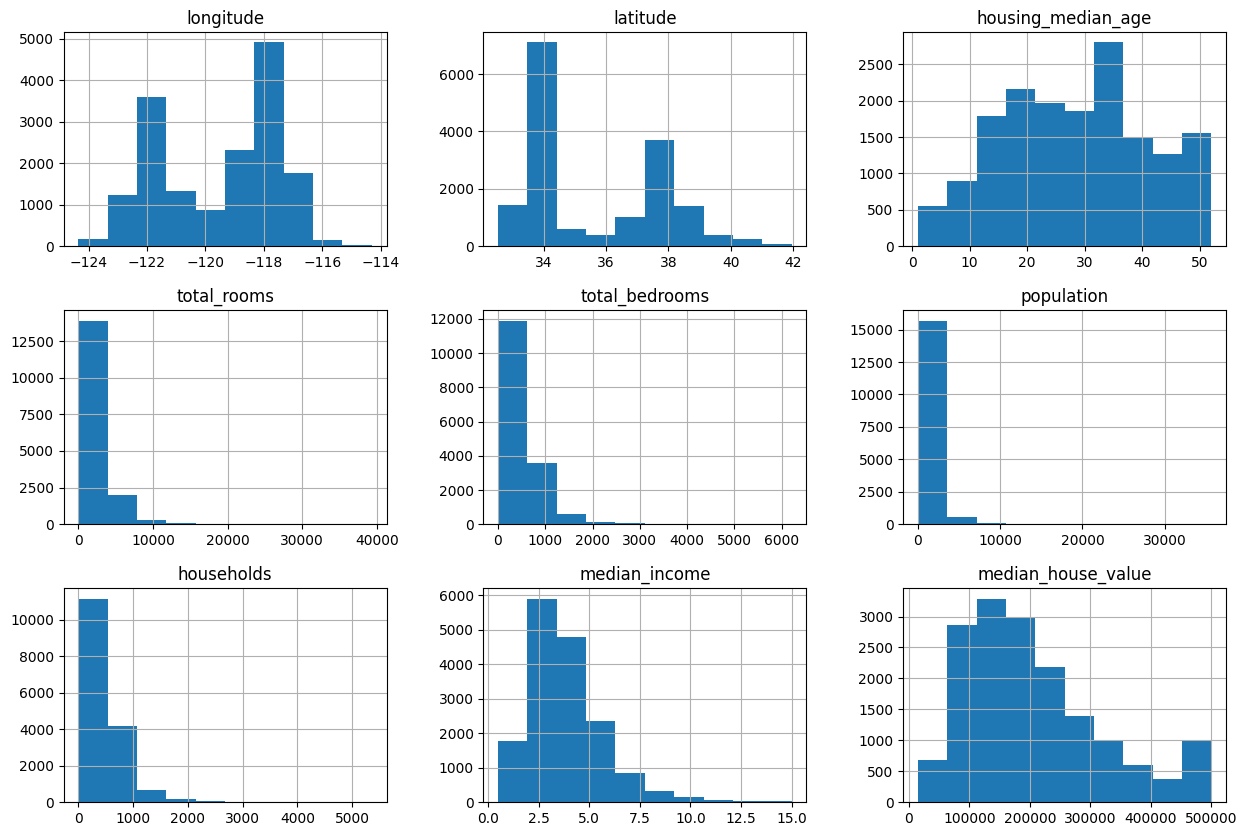

In [10]:
train_data.hist(figsize=(15,10))

In [11]:
train_data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925243,-0.110881,0.051977,0.075054,0.107866,0.062772,-0.007573,-0.040123
latitude,-0.925243,1.000000,0.014038,-0.040373,-0.070177,-0.113558,-0.075388,-0.085727,-0.148408
housing_median_age,-0.110881,0.014038,1.000000,-0.363813,-0.320970,-0.298326,-0.304069,-0.120175,0.109253
total_rooms,0.051977,-0.040373,-0.363813,1.000000,0.929533,0.852163,0.916954,0.198696,0.130044
total_bedrooms,0.075054,-0.070177,-0.320970,0.929533,1.000000,0.873236,0.978769,-0.010308,0.043817
population,0.107866,-0.113558,-0.298326,0.852163,0.873236,1.000000,0.903981,0.004283,-0.029105
households,0.062772,-0.075388,-0.304069,0.916954,0.978769,0.903981,1.000000,0.010848,0.059359
median_income,-0.007573,-0.085727,-0.120175,0.198696,-0.010308,0.004283,0.010848,1.000000,0.689665
median_house_value,-0.040123,-0.148408,0.109253,0.130044,0.043817,-0.029105,0.059359,0.689665,1.000000


<Axes: >

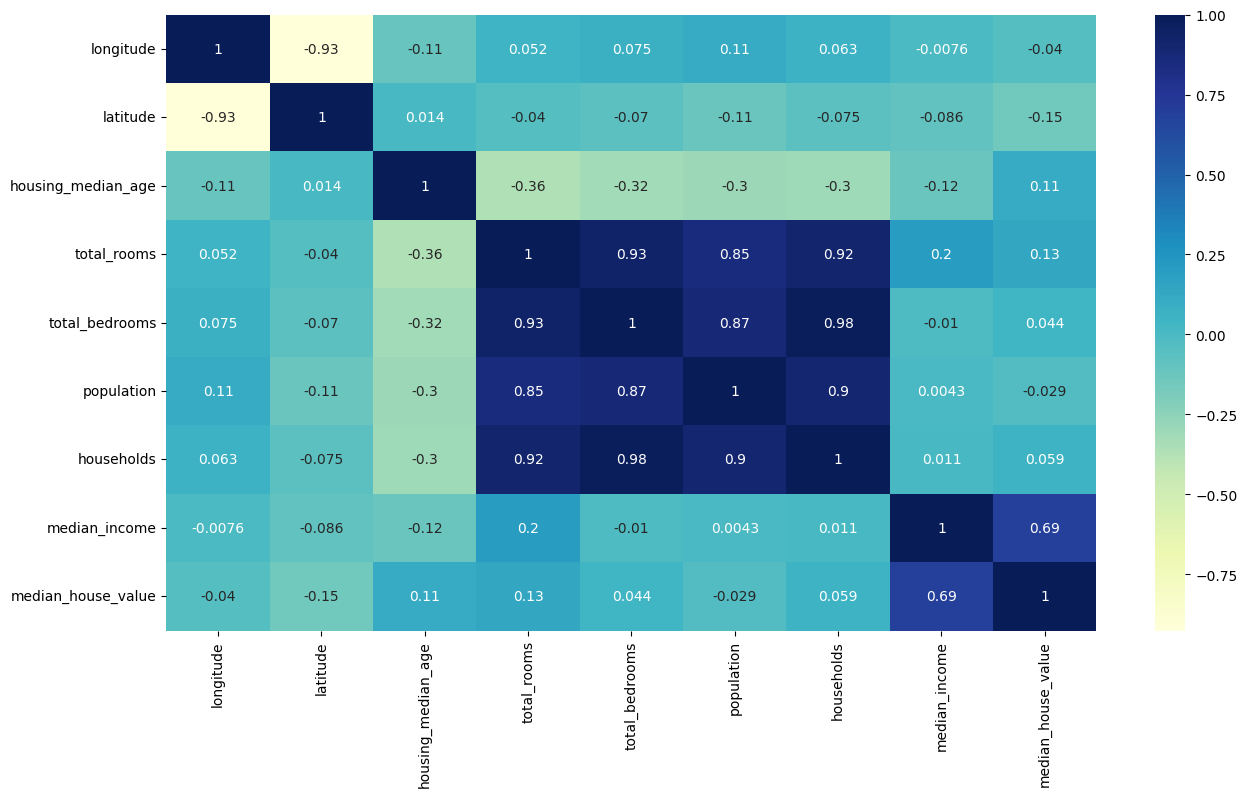

In [12]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot = True, cmap = 'YlGnBu')

In [13]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

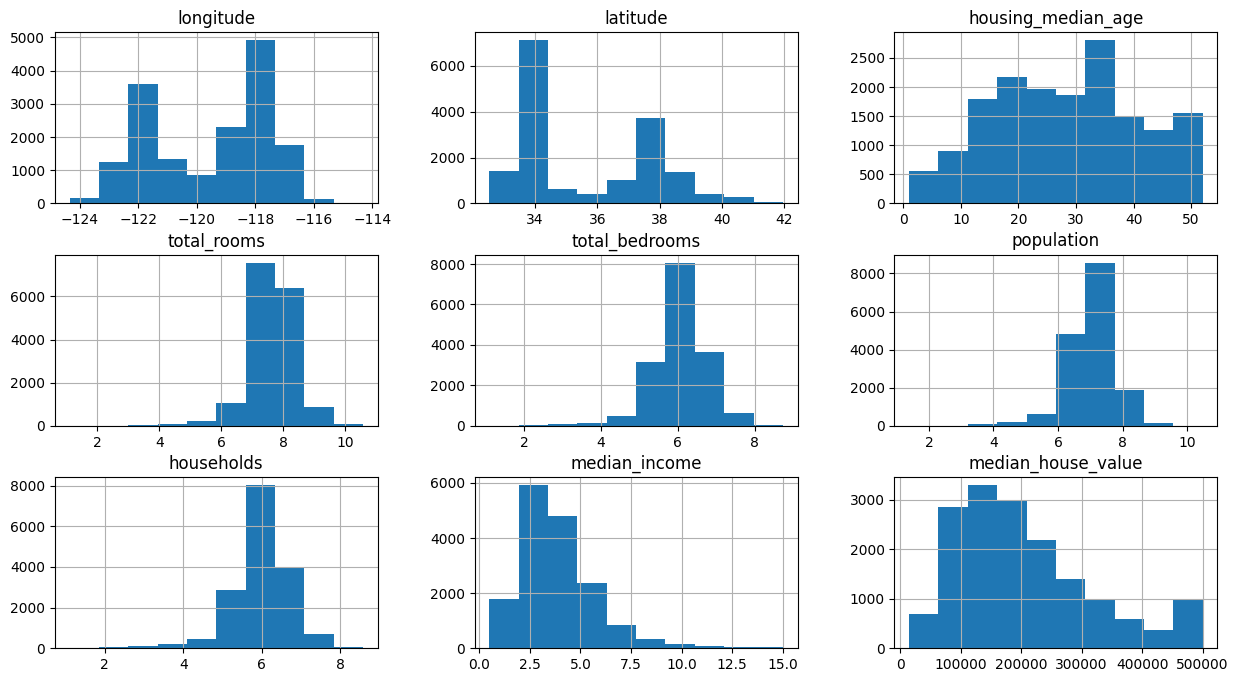

In [14]:
train_data.hist(figsize=(15,8))

In [15]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity, dtype = int)).drop(['ocean_proximity'], axis = 1)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
8922,-118.49,34.02,28,7.240650,6.368187,6.575076,6.298949,1.5132,450000,1,0,0,0,0
1212,-120.55,38.07,27,7.090077,5.416100,6.139885,5.298317,2.9063,92200,0,1,0,0,0
10083,-120.21,39.35,7,6.818924,5.075174,4.454347,3.555348,4.7917,187500,0,1,0,0,0
4764,-118.36,34.04,45,7.477604,6.035481,6.959399,5.940171,3.5161,157000,1,0,0,0,0
13551,-117.31,34.11,38,7.097549,5.774552,7.111512,5.762051,1.4663,64000,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19493,-121.00,37.67,27,7.731492,6.173786,6.903747,6.109248,2.5148,110200,0,1,0,0,0
10483,-117.68,33.59,8,7.752765,5.575949,6.802395,5.468060,14.9009,500001,1,0,0,0,0
186,-122.23,37.79,52,7.486613,5.981414,7.414573,6.023448,2.9357,107900,0,0,0,1,0
20327,-119.06,34.24,21,8.914223,6.892642,8.000685,6.896694,7.6775,391200,1,0,0,0,0


<Axes: >

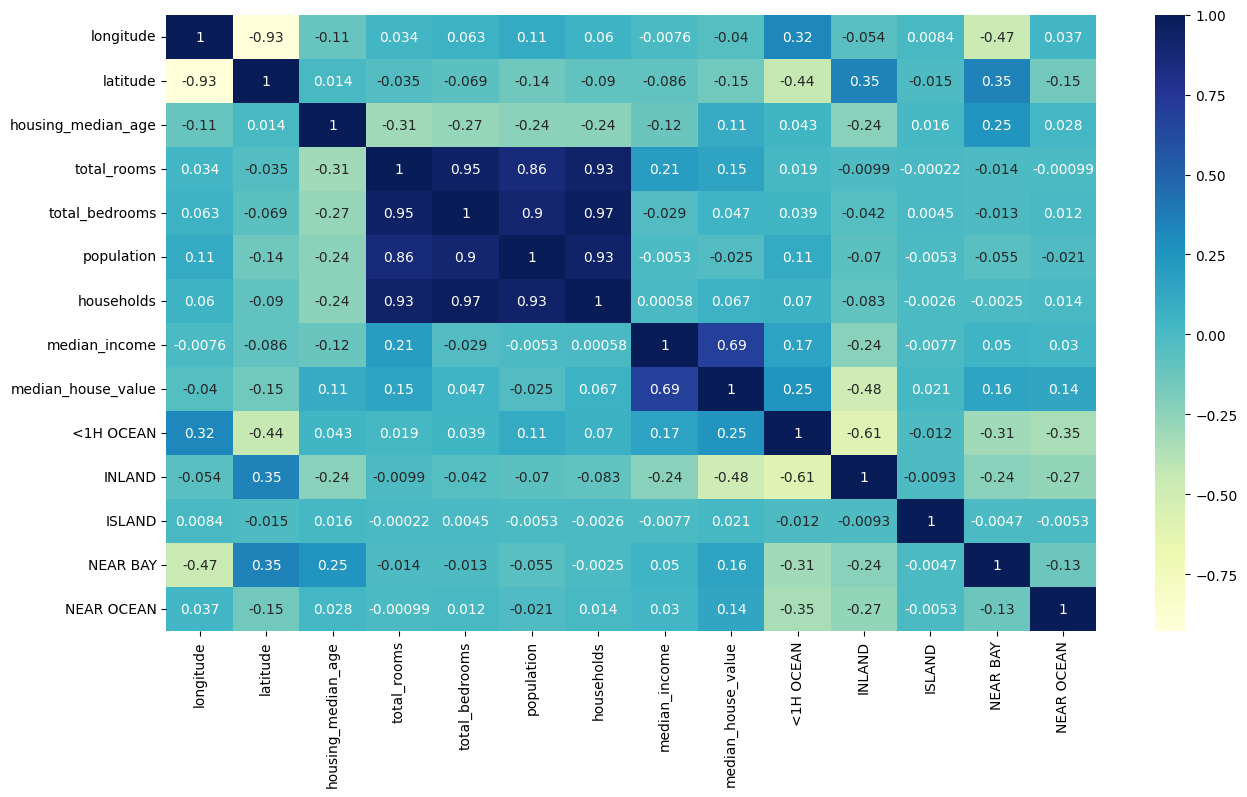

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot = True, cmap = 'YlGnBu')

<Axes: xlabel='latitude', ylabel='longitude'>

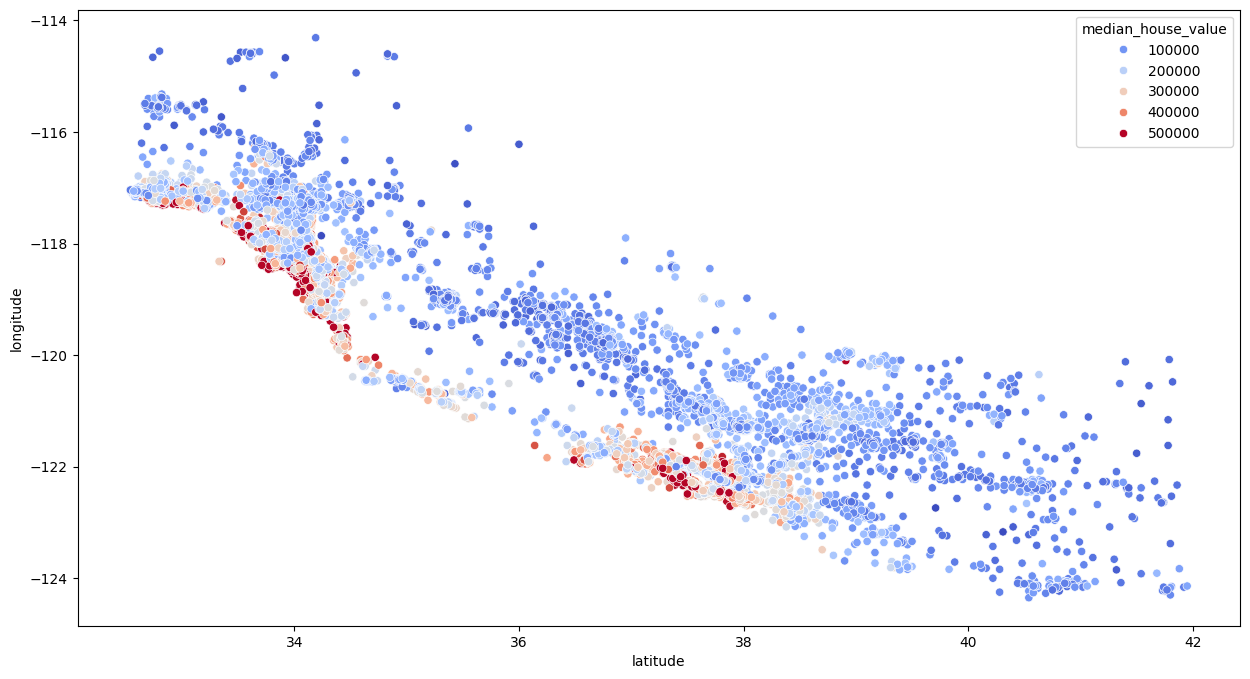

In [17]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude', y='longitude', data=train_data, hue='median_house_value', palette='coolwarm')

In [18]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

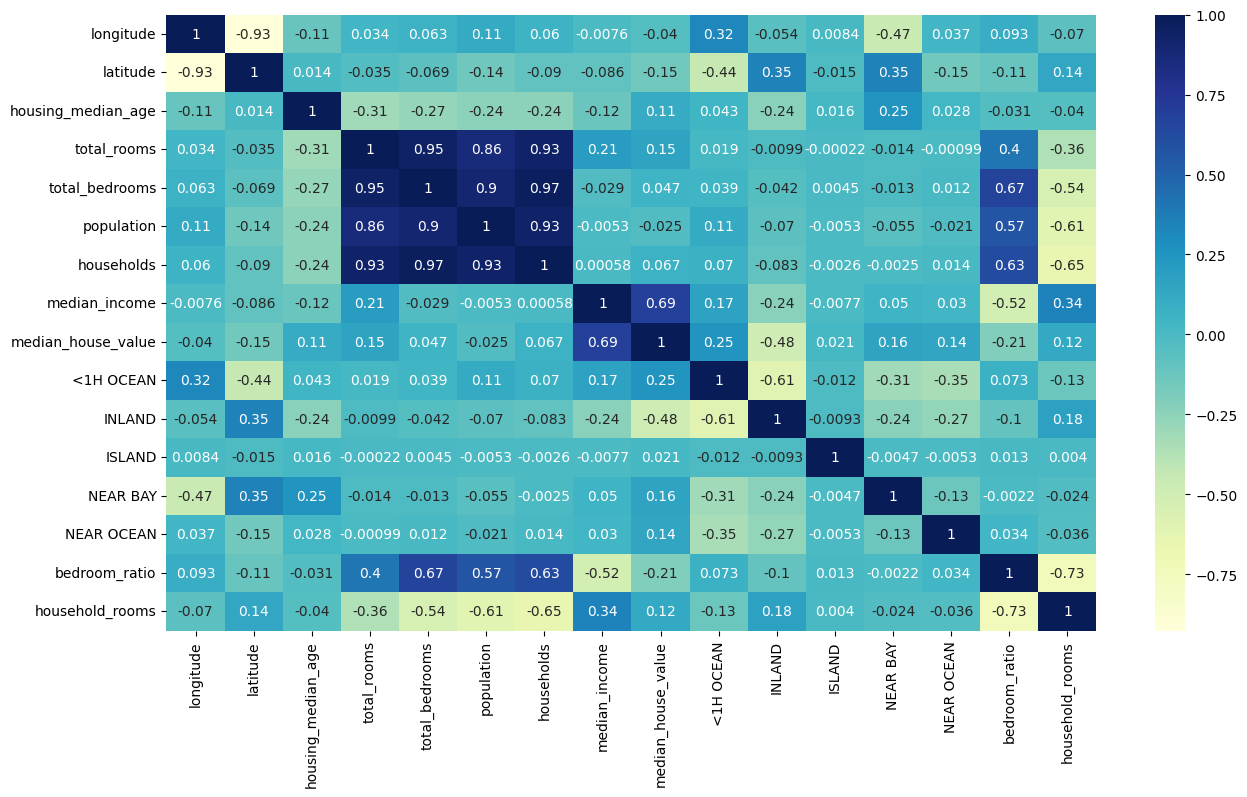

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot = True, cmap = 'YlGnBu')

In [20]:
from sklearn.linear_model import LinearRegression

X_train, y_train = train_data.drop(['median_house_value'], axis = 1), train_data['median_house_value']

reg = LinearRegression()

reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity, dtype = int)).drop(['ocean_proximity'], axis = 1)
test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']


In [22]:
X_test, y_test = test_data.drop(['median_house_value'], axis = 1), test_data['median_house_value']

In [23]:
reg.score(X_test, y_test)

0.6698520410871349

In [24]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
forest.score(X_test, y_test)

0.8198699241831225

In [26]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    'n_estimators': [3,10,30],
    'max_features': [2, 4, 6, 8]    
}

grid_search = GridSearchCV(forest, param_grid, cv=5, scoring = 'neg_mean_squared_error', return_train_score = True)
grid_search.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [27]:
best_forest = grid_search.best_estimator_
best_forest

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
best_forest.score(X_test, y_test)

0.8156796861209243